In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, average_precision_score
import time
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.stats import pearsonr
import seaborn as sns
import shap
import os
from datetime import datetime
import textwrap
from collections import Counter

In [2]:
# Time tracking
prepare_start_time = time.time()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Load the dataset
file_path_cold = "../../NewDataset/dataset_1_smaller.csv"
df = pd.read_csv(file_path_cold, encoding="ascii")

X = df.drop(columns=[
                    "is_courier_grabbed", 
                    "is_weekend",
                    "is_prebook",
                    ])
y_class = df["is_courier_grabbed"]  # Object Classification
y_class2 = df["is_weekend"]  # Obiect Classification2
y_class3 = df["is_prebook"]  # Object Classification3
y_class_name = y_class.name if hasattr(y_class, 'name') else "Classification Target"
y_class2_name = y_class2.name if hasattr(y_class2, 'name') else "Classification Target2"
y_class3_name = y_class3.name if hasattr(y_class3, 'name') else "Classification Target3"

# Mapping the trimming code to 0, 1, 2, ...
le_class = LabelEncoder()
y_class_mapped = le_class.fit_transform(y_class)  
num_classes = len(le_class.classes_)  
print(f"y_class_mapped dtype: {y_class_mapped.dtype}")
print(f"Original y_class: min={y_class.min()}, max={y_class.max()}")
print(f"Mapped y_class_mapped: min={y_class_mapped.min()}, max={y_class_mapped.max()}")

le_class2 = LabelEncoder()
y_class2_mapped = le_class2.fit_transform(y_class2)
num_classes2 = len(le_class2.classes_)
print(f"y_class2_mapped dtype: {y_class2_mapped.dtype}")
print(f"Original y_class2: min={y_class2.min()}, max={y_class2.max()}")
print(f"Mapped y_class2_mapped: min={y_class2_mapped.min()}, max={y_class2_mapped.max()}")

le_class3 = LabelEncoder()
y_class3_mapped = le_class3.fit_transform(y_class3)
num_classes3 = len(le_class3.classes_)
print(f"y_class3_mapped dtype: {y_class3_mapped.dtype}")
print(f"Original y_class3: min={y_class3.min()}, max={y_class3.max()}")
print(f"Mapped y_class3_mapped: min={y_class3_mapped.min()}, max={y_class3_mapped.max()}")


# Data standardization (standardization of all features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Remove the rows with NaN values
X_scaled_clean = X_scaled[~np.isnan(X_scaled).any(axis=1)]
y_class_train_clean = y_class_mapped[~np.isnan(X_scaled).any(axis=1)]
y_class2_train_clean = y_class2_mapped[~np.isnan(X_scaled).any(axis=1)]
y_class3_train_clean = y_class3_mapped[~np.isnan(X_scaled).any(axis=1)]

# Split the dataset into training (80%), validation (10%), and test (10%)
X_train, X_temp, y_class_train, y_class_temp, y_class2_train, y_class2_temp, y_class3_train, y_class3_temp = train_test_split(
    X_scaled_clean, y_class_train_clean, y_class2_train_clean, y_class3_train_clean, test_size=0.2, random_state=42, 
)
X_val, X_test, y_class_val, y_class_test, y_class2_val, y_class2_test, y_class3_val, y_class3_test = train_test_split(
    X_temp, y_class_temp, y_class2_temp, y_class3_temp, test_size=0.5, random_state=42, 
)

# Convert to PyTorch tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

y_class_train_tensor = torch.tensor(y_class_train, dtype=torch.long).to(device)
y_class_val_tensor   = torch.tensor(y_class_val, dtype=torch.long).to(device)
y_class_test_tensor  = torch.tensor(y_class_test, dtype=torch.long).to(device)

y_class2_train_tensor = torch.tensor(y_class2_train, dtype=torch.long).to(device)
y_class2_val_tensor   = torch.tensor(y_class2_val, dtype=torch.long).to(device)
y_class2_test_tensor  = torch.tensor(y_class2_test, dtype=torch.long).to(device)

y_class3_train_tensor = torch.tensor(y_class3_train, dtype=torch.long).to(device)  # NEW
y_class3_val_tensor   = torch.tensor(y_class3_val, dtype=torch.long).to(device)    # NEW
y_class3_test_tensor  = torch.tensor(y_class3_test, dtype=torch.long).to(device)   # NEW

# DataLoader for train, validation, and test sets
train_dataset = TensorDataset(X_train_tensor, y_class_train_tensor, y_class2_train_tensor, y_class3_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_class_val_tensor, y_class2_val_tensor, y_class3_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_class_test_tensor, y_class2_test_tensor, y_class3_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print information for verification
print(f"y_class_train_tensor type: {y_class_train_tensor.dtype}; min: {y_class_train_tensor.min()}; max: {y_class_train_tensor.max()}")
print(f"y_class2_train_tensor type: {y_class2_train_tensor.dtype}; min: {y_class2_train_tensor.min()}; max: {y_class2_train_tensor.max()}")
print(f"y_class3_train_tensor type: {y_class3_train_tensor.dtype}; min: {y_class3_train_tensor.min()}; max: {y_class3_train_tensor.max()}")


y_class_mapped dtype: int64
Original y_class: min=0, max=1
Mapped y_class_mapped: min=0, max=1
y_class2_mapped dtype: int64
Original y_class2: min=0, max=1
Mapped y_class2_mapped: min=0, max=1
y_class3_mapped dtype: int64
Original y_class3: min=0, max=1
Mapped y_class3_mapped: min=0, max=1
y_class_train_tensor type: torch.int64; min: 0; max: 1
y_class2_train_tensor type: torch.int64; min: 0; max: 1
y_class3_train_tensor type: torch.int64; min: 0; max: 1


In [4]:
# Check for NaN or Inf in the training set
print(torch.isnan(X_train_tensor).any())  # Check if there is NaN in the input
print(torch.isinf(X_train_tensor).any())  # Check if there is Inf in the input
print(torch.isnan(y_class_train_tensor).any())  # Check if there is NaN in the first classification label
print(torch.isinf(y_class_train_tensor).any())  # Check if there is Inf in the first classification label
print(torch.isnan(y_class2_train_tensor).any())  # Check if there is NaN in the second classification label
print(torch.isinf(y_class2_train_tensor).any())  # Check if there is Inf in the second classification label
print(torch.isnan(y_class3_train_tensor).any())  # Check if there is NaN in the third classification label
print(torch.isinf(y_class3_train_tensor).any())  # Check if there is Inf in the third classification label

# Check for NaN or Inf in the validation set
print(torch.isnan(X_val_tensor).any())  # Check if there is NaN in the input
print(torch.isinf(X_val_tensor).any())  # Check if there is Inf in the input
print(torch.isnan(y_class_val_tensor).any())  # Check if there is NaN in the first classification label
print(torch.isinf(y_class_val_tensor).any())  # Check if there is Inf in the first classification label
print(torch.isnan(y_class2_val_tensor).any())  # Check if there is NaN in the second classification label
print(torch.isinf(y_class2_val_tensor).any())  # Check if there is Inf in the second classification label
print(torch.isnan(y_class3_val_tensor).any())  # Check if there is NaN in the third classification label
print(torch.isinf(y_class3_val_tensor).any())  # Check if there is Inf in the third classification label

# Check for NaN or Inf in the test set
print(torch.isnan(X_test_tensor).any())  # Check if there is NaN in the input
print(torch.isinf(X_test_tensor).any())  # Check if there is Inf in the input
print(torch.isnan(y_class_test_tensor).any())  # Check if there is NaN in the first classification label
print(torch.isinf(y_class_test_tensor).any())  # Check if there is Inf in the first classification label
print(torch.isnan(y_class2_test_tensor).any())  # Check if there is NaN in the second classification label
print(torch.isinf(y_class2_test_tensor).any())  # Check if there is Inf in the second classification label
print(torch.isnan(y_class3_test_tensor).any())  # Check if there is NaN in the third classification label
print(torch.isinf(y_class3_test_tensor).any())  # Check if there is Inf in the third classification label


tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')


In [5]:
# ---------------------------
# Dataset size summary
# ---------------------------
print("\n===== Dataset Size Summary =====")
print(f"X_train: {X_train.shape}, y_class_train: {len(y_class_train_tensor)}")
print(f"X_val:   {X_val.shape},   y_class_val:   {len(y_class_val_tensor)}")
print(f"X_test:  {X_test.shape},  y_class_test:  {len(y_class_test_tensor)}")

print("\nNumber of samples:")
print(f"Train set: {len(train_dataset)}")
print(f"Val set:   {len(val_dataset)}")
print(f"Test set:  {len(test_dataset)}")

print("\nBatches per DataLoader:")
print(f"train_loader batches: {len(train_loader)}")
print(f"val_loader batches:   {len(val_loader)}")
print(f"test_loader batches:  {len(test_loader)}")


# ---------------------------
# Class distributions
# ---------------------------
def print_class_stats(name, y_tensor):
    print(f"\n{name} class distribution:")
    values, counts = torch.unique(y_tensor, return_counts=True)
    for v, c in zip(values.tolist(), counts.tolist()):
        print(f"  Class {v}: {c} samples")

print_class_stats("y_class_train", y_class_train_tensor)
print_class_stats("y_class2_train", y_class2_train_tensor)
print_class_stats("y_class3_train", y_class3_train_tensor)

print_class_stats("y_class_val", y_class_val_tensor)
print_class_stats("y_class2_val", y_class2_val_tensor)
print_class_stats("y_class3_val", y_class3_val_tensor)

print_class_stats("y_class_test", y_class_test_tensor)
print_class_stats("y_class2_test", y_class2_test_tensor)
print_class_stats("y_class3_test", y_class3_test_tensor)



===== Dataset Size Summary =====
X_train: (52347, 22), y_class_train: 52347
X_val:   (6543, 22),   y_class_val:   6543
X_test:  (6544, 22),  y_class_test:  6544

Number of samples:
Train set: 52347
Val set:   6543
Test set:  6544

Batches per DataLoader:
train_loader batches: 818
val_loader batches:   103
test_loader batches:  103

y_class_train class distribution:
  Class 0: 6906 samples
  Class 1: 45441 samples

y_class2_train class distribution:
  Class 0: 38031 samples
  Class 1: 14316 samples

y_class3_train class distribution:
  Class 0: 50450 samples
  Class 1: 1897 samples

y_class_val class distribution:
  Class 0: 848 samples
  Class 1: 5695 samples

y_class2_val class distribution:
  Class 0: 4786 samples
  Class 1: 1757 samples

y_class3_val class distribution:
  Class 0: 6293 samples
  Class 1: 250 samples

y_class_test class distribution:
  Class 0: 870 samples
  Class 1: 5674 samples

y_class2_test class distribution:
  Class 0: 4785 samples
  Class 1: 1759 samples

y_c

In [6]:
# Define Transformer Model
class TransformerTwoStage(nn.Module):
    def __init__(self, input_dim, num_classes, num_classes2, num_classes3, embedding_dim=8, embedding_dim_2=8, hidden_dim=128, num_heads=8, num_layers=2, dropout=0.4):
        super(TransformerTwoStage, self).__init__()
        self.num_classes = num_classes
        self.num_classes2 = num_classes2
        self.num_classes3 = num_classes3
        self.hidden_dim = hidden_dim
        
        # Embedding layers
        self.trim_code_embedding = nn.Embedding(num_classes, embedding_dim)
        self.trim_code_embedding_2 = nn.Embedding(num_classes2, embedding_dim_2)
        
        self.embedding = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim)
        )
        # residual projection for embedding
        self.embedding_residual = nn.Linear(input_dim, hidden_dim)  # residual projection
        self.embedding_gate = nn.Linear(hidden_dim, hidden_dim)  # gate projection
        # positional encoding
        self.positional_encoding = nn.Parameter(torch.zeros(1, 1, hidden_dim))
    
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # heads
        # classification head 1
        self.classifier_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4),
            nn.LayerNorm(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, num_classes)
        )
        # residual projection for classification
        self.classifier_residual = nn.Linear(hidden_dim, num_classes)  # for residual
        self.classifier_gate = nn.Linear(num_classes, num_classes)  # gate projection
        
        # ----------- classification head 2 -----------
        self.classifier_head2 = nn.Sequential(
            nn.Linear(hidden_dim + embedding_dim, hidden_dim // 4),
            nn.LayerNorm(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, num_classes2)
        )
        # residual projection for classification 2
        self.classifier_residual2 = nn.Linear(hidden_dim + embedding_dim, num_classes2)  
        self.classifier_gate2 = nn.Linear(num_classes2, num_classes2) 
        
        # -----------------------
        # Head3 (input = cls_token + embedding(head2_pred))
        # -----------------------
        self.classifier_head3 = nn.Sequential(
            nn.Linear(hidden_dim + embedding_dim_2, hidden_dim // 4),
            nn.LayerNorm(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, num_classes3)
        )
        self.classifier_residual3 = nn.Linear(hidden_dim + embedding_dim_2, num_classes3)
        self.classifier_gate3 = nn.Linear(num_classes3, num_classes3)
        
    def _init_gates(self):
        def init_gate(layer):
            nn.init.constant_(layer.bias, 0.0)
            nn.init.xavier_uniform_(layer.weight, gain=0.5)

        for gate in [self.embedding_gate, self.classifier_gate, self.classifier_gate2, self.classifier_gate3]:
            init_gate(gate)

    def gated_residual(self, main_out, residual_in, gate_layer):
        gate = torch.sigmoid(gate_layer(main_out))
        gate = torch.clamp(gate, min=0.1, max=0.9)
        return main_out * gate + residual_in * (1 - gate)
    
    def gate_regularization(self, x, class_logits, class_logits2, class_logits3, lambda_emb1=1.0, lambda_cls=1.0, lambda_cls2=1.0, lambda_cls3=1.0):
        """
        Regularizes the gates to stay near 0.5 (to encourage learning sparse residual paths).
        Input:
            x: input batch (B, input_dim)
            class_logits: (B, num_classes)
            class_logits2: (B,)
        Returns:
            scalar loss term (mean absolute deviation from 0.5)
        """
        # -------- 1️⃣ Embedding gate (first) --------
        x_main = self.embedding(x)  # (B, hidden)
        x_residual = self.embedding_residual(x)  # (B, hidden)
        gate1_input = x_main
        gate1 = torch.sigmoid(self.embedding_gate(gate1_input))  # (B, hidden)
        gate1_loss = torch.mean(torch.abs(gate1 - 0.5))

        # Transformer encoder for attention mechanism
        x_embed = self.gated_residual(x_main, x_residual, self.embedding_gate).unsqueeze(1)  # (B, 1, hidden)
        x_embed = x_embed + self.positional_encoding[:, :1, :]
        x_encoded = self.transformer_encoder(x_embed)  # (B, 1, hidden)
        x_encoded_residual = x_encoded.squeeze(1)
        
        # -------- 2️⃣ Classifier gate --------
        cls_token = self.gated_residual(x_encoded_residual, x_embed.squeeze(1), self.embedding_gate)
        class_logits_main = self.classifier_head(cls_token)
        gate2_input = class_logits_main
        gate2 = torch.sigmoid(self.classifier_gate(gate2_input))  # (B, num_classes)
        gate2_loss = torch.mean(torch.abs(gate2 - 0.5))

        # -------- 3️⃣ Classifier2 gate --------
        pred_trim_code = torch.argmax(class_logits, dim=1)
        trim_code_embed = self.trim_code_embedding(pred_trim_code)
        cls2_input = torch.cat([cls_token, trim_code_embed], dim=1)
        class_logits_main2 = self.classifier_head2(cls2_input)
        gate3 = torch.sigmoid(self.classifier_gate2(class_logits_main2))  # (B, num_classes2)
        gate3_loss = torch.mean(torch.abs(gate3 - 0.5))
        
        # ================================================================
        #           4️⃣ Classifier3 gate
        # ================================================================
        # Use the output class_logits2 of your previous head2
        pred_trim_code2 = torch.argmax(class_logits2, dim=1)  
        trim_code_embed2 = self.trim_code_embedding_2(pred_trim_code2)
        cls3_input = torch.cat([cls_token, trim_code_embed2], dim=1)
        class_logits_main3 = self.classifier_head3(cls3_input)
        gate4 = torch.sigmoid(self.classifier_gate3(class_logits_main3))
        gate4_loss = torch.mean(torch.abs(gate4 - 0.5))
        
        # Total loss
        total_loss = (
            lambda_emb1 * gate1_loss +
            lambda_cls * gate2_loss +
            lambda_cls2 * gate3_loss+
            lambda_cls3 * gate4_loss
        )
        return total_loss

    def forward(self, x, trim_code=None, trim_code2=None):
        # ----------- Embedding and Attention Stage -----------
        x_main = self.embedding(x)  # (B, hidden)
        x_residual = self.embedding_residual(x)  # (B, hidden)
        x_embed = self.gated_residual(x_main, x_residual, self.embedding_gate)  # residual connection
        
        # Adding positional encoding to the embedding
        x_embed = x_embed.unsqueeze(1) + self.positional_encoding[:, :1, :] # (B, 1, hidden)
        
        # Transformer encoder for attention mechanism
        x_encoded = self.transformer_encoder(x_embed)# (B, 1, hidden)
        
        # AutoInt-style residual after attention (incorporate residuals)
        x_encoded_residual = x_encoded.squeeze(1)  # (B, hidden)
        x_encoded_with_residual = self.gated_residual(x_encoded_residual, x_embed.squeeze(1), self.embedding_gate)  # Add residual to output
        cls_token = x_encoded_with_residual  # (B, hidden)
        
        # ----------- classification stage -----------
        class_logits_main = self.classifier_head(cls_token) # Main classification head output
        class_residual = self.classifier_residual(cls_token) # Residual projection for classification
        class_logits = self.gated_residual(class_logits_main, class_residual, self.classifier_gate)  # residual connection
        
        # ----------- classification stage2 -----------
        # Step1: predict class and get the class token
        if trim_code is None:
        # Use the predicted values of the classification results instead of the true trim_code
            trim_code = torch.argmax(class_logits, dim=1)  # (B, )

        # Step2: concatenate the class token with the input features
        trim_code_embed = self.trim_code_embedding(trim_code)  # (B, embedding_dim)
        cls2_input = torch.cat([cls_token, trim_code_embed], dim=-1)  # (B, input_dim + num_classes)

        # Step3: pass through the same transformer encoder
        class_logits_main2 = self.classifier_head2(cls2_input)  # (B, num_classes2)
        class_residual2 = self.classifier_residual2(cls2_input)
        class_logits2 = self.gated_residual(class_logits_main2, class_residual2, self.classifier_gate2)  # residual connection
        
        # ----------- classification stage3 -----------
        if trim_code2 is None:
        # Use the predicted values of the classification results instead of the true trim_code2
            trim_code2 = torch.argmax(class_logits2, dim=1)
            
        # Step2: concatenate the class token with the input features
        trim_code_embed2 = self.trim_code_embedding_2(trim_code2)
        cls3_input = torch.cat([cls_token, trim_code_embed2], dim=1)
        
        # Step3: pass through the same transformer encoder
        class_logits_main3 = self.classifier_head3(cls3_input)
        class_residual3 = self.classifier_residual3(cls3_input)
        class_logits3 = self.gated_residual(class_logits_main3, class_residual3, self.classifier_gate3)
        
        return class_logits, class_logits2, class_logits3

# Initialization model
# Model, Loss, and Optimizer
num_classes = y_class_mapped.max() + 1  # 0 to 5 
num_classes2 = y_class2_mapped.max() + 1  
num_classes3 = y_class3_mapped.max() + 1   

model = TransformerTwoStage(input_dim=X.shape[1], num_classes=num_classes, num_classes2=num_classes2, num_classes3=num_classes3,).to(device)
criterion_class = nn.CrossEntropyLoss()
criterion_class2 = nn.CrossEntropyLoss()
criterion_class3 = nn.CrossEntropyLoss() 
# criterion_reg = nn.SmoothL1Loss()
# criterion_reg = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
class_weight = 2.2  # Weight for class loss
class_weight2 = 1.0  # Weight for class2 loss
class_weight3 = 0.8  # Weight for class3 loss
num_epochs = 30 # Number of epochs for training
gate_weight = 0.01  # Weight for gate regularization
# Regularization weights for gates
lambda_emb1=1
lambda_cls=1
lambda_cls2=1
lambda_cls3 = 1
best_val_loss = float("inf")
train_losses = []
val_losses = []
print(model)

# Calculate and print the prepare time
prepare_end_time = time.time()
total_prepare_time = prepare_end_time - prepare_start_time
print(f"\nTotal load and prepare time: {total_prepare_time:.2f} seconds")

TransformerTwoStage(
  (trim_code_embedding): Embedding(2, 8)
  (trim_code_embedding_2): Embedding(2, 8)
  (embedding): Sequential(
    (0): Linear(in_features=22, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
  )
  (embedding_residual): Linear(in_features=22, out_features=128, bias=True)
  (embedding_gate): Linear(in_features=128, out_features=128, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.4, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1)

a:\Anaconda\envs\Utility_prediction\lib\site-packages\torch\nn\functional.py:5560: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


Epoch 1/30, Training Loss: 1.1159
Epoch 1/30, Validation Loss: 1.0018
Best model saved at epoch 1 with validation loss: 1.0018
Epoch 2/30, Training Loss: 0.9985
Epoch 2/30, Validation Loss: 0.9817
Best model saved at epoch 2 with validation loss: 0.9817
Epoch 3/30, Training Loss: 0.9783
Epoch 3/30, Validation Loss: 0.9648
Best model saved at epoch 3 with validation loss: 0.9648
Epoch 4/30, Training Loss: 0.9649
Epoch 4/30, Validation Loss: 0.9522
Best model saved at epoch 4 with validation loss: 0.9522
Epoch 5/30, Training Loss: 0.9521
Epoch 5/30, Validation Loss: 0.9374
Best model saved at epoch 5 with validation loss: 0.9374
Epoch 6/30, Training Loss: 0.9397
Epoch 6/30, Validation Loss: 0.9221
Best model saved at epoch 6 with validation loss: 0.9221
Epoch 7/30, Training Loss: 0.9282
Epoch 7/30, Validation Loss: 0.9035
Best model saved at epoch 7 with validation loss: 0.9035
Epoch 8/30, Training Loss: 0.9138
Epoch 8/30, Validation Loss: 0.8880
Best model saved at epoch 8 with validati

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


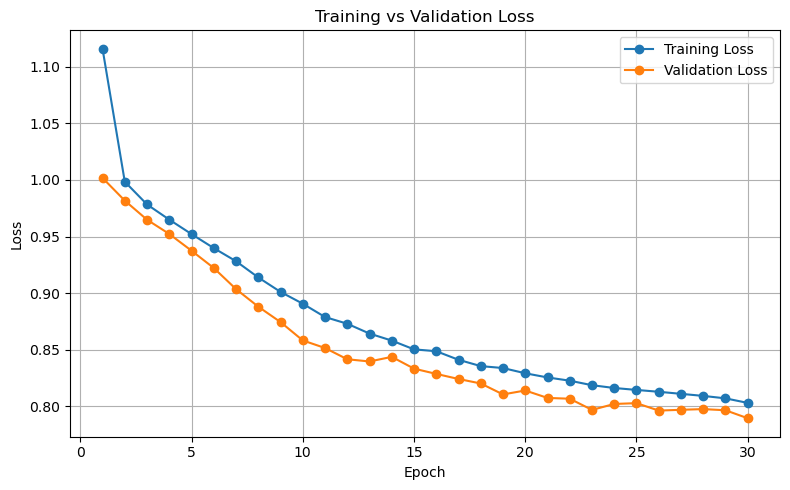

In [7]:
# Time tracking
train_start_time = time.time()

# Training Loop with Validation and Model Saving
model.train()
for epoch in range(num_epochs):
    total_loss = 0
    model.train()
    for X_batch, y_class_batch, y_class2_batch, y_class3_batch  in train_loader:
        assert (y_class_batch >= 0).all(), f"Found negative labels in class: {y_class_batch}"
        assert (y_class2_batch >= 0).all(), f"Found negative labels in class2: {y_class2_batch}"
        assert (y_class3_batch >= 0).all(), f"Found negative labels in class3: {y_class3_batch}"
        X_batch = X_batch.to(device)
        y_class_batch = y_class_batch.to(device)
        y_class2_batch = y_class2_batch.to(device)
        y_class3_batch = y_class3_batch.to(device)
        
        optimizer.zero_grad()

        # Forward pass through the model (first predicts the Trim Code, then the Voltage)
        class_logits, class_logits2, class_logits3 = model(X_batch, y_class_batch)  # No need to pass trim_code_onehot anymore since model handles it
        loss_class = criterion_class(class_logits, y_class_batch)
        loss_class2 = criterion_class2(class_logits2, y_class2_batch)
        loss_class3 = criterion_class3(class_logits3, y_class3_batch)
        gate_reg_loss = model.gate_regularization(X_batch, class_logits, class_logits2, class_logits3, lambda_emb1=lambda_emb1, lambda_cls=lambda_cls, lambda_cls2=lambda_cls2, lambda_cls3=lambda_cls3)
        
        # --------- Total loss ---------
        # Total loss = classification + classification2 + gate reg
        loss = class_weight * loss_class + class_weight2 * loss_class2 + class_weight3 * loss_class3 + gate_weight * gate_reg_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {avg_train_loss:.4f}")

    # Validation phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_class_batch, y_class2_batch, y_class3_batch in test_loader:
            X_batch = X_batch.to(device)
            y_class_batch = y_class_batch.to(device)
            y_class2_batch = y_class2_batch.to(device)
            y_class3_batch = y_class3_batch.to(device)
            trim_code_onehot = F.one_hot(y_class_batch, num_classes=num_classes).float()
            class_logits, class_logits2, class_logits3 = model(X_batch, y_class_batch)  # Same here: model handles it internally
            loss_class = criterion_class(class_logits, y_class_batch)
            loss_class2 = criterion_class2(class_logits2, y_class2_batch)
            loss_class3 = criterion_class3(class_logits3, y_class3_batch)
            loss = class_weight * loss_class + class_weight2 * loss_class2 + class_weight3 * loss_class3
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Validation Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_Residual_TransformerTwoStage.pth")
        print(f"Best model saved at epoch {epoch+1} with validation loss: {avg_val_loss:.4f}")

# Calculate and print the training time
train_end_time = time.time()
total_train_time = train_end_time - train_start_time
print(f"\nTotal Transformer training time: {total_train_time:.2f} seconds")

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
# Save figure as EPS (Encapsulated PostScript)
plt.savefig("Voltage_training_validation_loss.jpg", format='jpg', dpi=300)
plt.savefig("Voltage_training_validation_loss.eps", format='eps', dpi=300)
plt.show()

In [8]:
# Load the best model
model.load_state_dict(torch.load("best_Residual_TransformerTwoStage.pth"))
print("Best Transformer model loaded.")

# Evaluation on Test Set
model.to(device)
model.eval()  # Switch the model to evaluation mode (disables dropout, etc.)
test_loss = 0
correct_classifications = 0
total_classifications = 0

correct_classifications2 = 0
total_classifications2 = 0

correct_classifications3 = 0
total_classifications3 = 0

# For classification metrics
all_class_preds = []
all_class_labels = []
all_class_preds_proba = []

# For classification2 metrics
all_class2_preds = []
all_class2_labels = []
all_class2_preds_proba = []

# For classification3 metrics
all_class3_preds = []
all_class3_labels = []
all_class3_preds_proba = []


with torch.no_grad():  # Disable gradient calculation to save memory and computations
    for X_batch, y_class_batch, y_class2_batch, y_class3_batch in test_loader:
        X_batch = X_batch.to(device)
        y_class_batch = y_class_batch.to(device)
        y_class2_batch  = y_class2_batch.to(device)
        y_class3_batch = y_class3_batch.to(device)
        # Forward pass through the model (no need to pass trim_code_onehot anymore)
        class_logits, class_logits2, class_logits3 = model(X_batch, y_class_batch, y_class2_batch)  #!!! Chose to use "X_batch" or "X_batch, y_class_batch: as input for the model
        
        # Classification loss
        loss_class = criterion_class(class_logits, y_class_batch)
        
        # Classification2 loss
        loss_class2 = criterion_class2(class_logits2, y_class2_batch)
        
        # Classification3 loss
        loss_class3 = criterion_class3(class_logits3, y_class3_batch)
        
        # Total loss
        loss = class_weight * loss_class + class_weight2 * loss_class2 + class_weight3 * loss_class3
        test_loss += loss.item()
        
        # Classification probability
        # --- First Classification Head ---
        num_classes = class_logits.shape[1]
        if num_classes == 2:
            class_probs = torch.softmax(class_logits, dim=1)[:, 1]  # binary
        else:
            class_probs = torch.softmax(class_logits, dim=1)  # multi-class
        all_class_preds_proba.append(class_probs.cpu().numpy())
        
        _, predicted_class = torch.max(class_logits, 1)
        correct_classifications += (predicted_class == y_class_batch).sum().item()
        total_classifications += y_class_batch.size(0)
        all_class_preds.extend(predicted_class.cpu().numpy())
        all_class_labels.extend(y_class_batch.cpu().numpy())
        
        # --- Second Classification Head ---
        num_classes2 = class_logits2.shape[1]
        if num_classes2 == 2:
            class2_probs = torch.softmax(class_logits2, dim=1)[:, 1]  # binary
        else:
            class2_probs = torch.softmax(class_logits2, dim=1)  # multi-class
        all_class2_preds_proba.append(class2_probs.cpu().numpy())
        
        _, predicted_class2 = torch.max(class_logits2, 1)
        correct_classifications2 += (predicted_class2 == y_class2_batch).sum().item()
        total_classifications2 += y_class2_batch.size(0)
        all_class2_preds.extend(predicted_class2.cpu().numpy())
        all_class2_labels.extend(y_class2_batch.cpu().numpy())
        
        # --- Third Classification Head ---
        num_classes3 = class_logits3.shape[1]
        if num_classes3 == 2:
            class3_probs = torch.softmax(class_logits3, dim=1)[:, 1]  # binary
        else:
            class3_probs = torch.softmax(class_logits3, dim=1)  # multi-class
        all_class3_preds_proba.append(class3_probs.cpu().numpy())
        
        _, predicted_class3 = torch.max(class_logits3, 1)
        correct_classifications3 += (predicted_class3 == y_class3_batch).sum().item()
        total_classifications3 += y_class3_batch.size(0)
        all_class3_preds.extend(predicted_class3.cpu().numpy())
        all_class3_labels.extend(y_class3_batch.cpu().numpy())

        

# Convert to numpy arrays for metric calculations
all_class_preds = np.array(all_class_preds)
all_class_labels = np.array(all_class_labels)
all_class2_preds = np.array(all_class2_preds)
all_class2_labels = np.array(all_class2_labels)
all_class3_preds = np.array(all_class3_preds)
all_class3_labels = np.array(all_class3_labels)


# ----------------- First Classification Head Metrics -----------------
classification_accuracy = correct_classifications / total_classifications

all_class_preds_proba = np.vstack(all_class_preds_proba) if len(all_class_preds_proba[0].shape) > 1 else np.concatenate(all_class_preds_proba)
if num_classes > 2:
    y_class_onehot = label_binarize(all_class_labels, classes=range(num_classes))
    auc = roc_auc_score(y_class_onehot, all_class_preds_proba, multi_class='ovr')
    aucpr = average_precision_score(y_class_onehot, all_class_preds_proba)
else:
    auc = roc_auc_score(all_class_labels, all_class_preds_proba)
    aucpr = average_precision_score(all_class_labels, all_class_preds_proba)

precision = precision_score(all_class_labels, all_class_preds, average='weighted', zero_division=0)
recall = recall_score(all_class_labels, all_class_preds, average='weighted', zero_division=0)
f1 = f1_score(all_class_labels, all_class_preds, average='weighted')

# ----------------- Second Classification Head Metrics -----------------
classification2_accuracy = correct_classifications2 / total_classifications2

all_class2_preds_proba = np.vstack(all_class2_preds_proba) if len(all_class2_preds_proba[0].shape) > 1 else np.concatenate(all_class2_preds_proba)
if num_classes2 > 2:
    y_class2_onehot = label_binarize(all_class2_labels, classes=range(num_classes2))
    auc2 = roc_auc_score(y_class2_onehot, all_class2_preds_proba, multi_class='ovr')
    aucpr2 = average_precision_score(y_class2_onehot, all_class2_preds_proba)
else:
    auc2 = roc_auc_score(all_class2_labels, all_class2_preds_proba)
    aucpr2 = average_precision_score(all_class2_labels, all_class2_preds_proba)

precision2 = precision_score(all_class2_labels, all_class2_preds, average='weighted', zero_division=0)
recall2 = recall_score(all_class2_labels, all_class2_preds, average='weighted', zero_division=0)
f12 = f1_score(all_class2_labels, all_class2_preds, average='weighted')

# ----------------- Third Classification Head Metrics -----------------
classification3_accuracy = correct_classifications3 / total_classifications3
all_class3_preds_proba = np.vstack(all_class3_preds_proba) if len(all_class3_preds_proba[0].shape) > 1 else np.concatenate(all_class3_preds_proba)

if num_classes3 > 2:
    y_class3_onehot = label_binarize(all_class3_labels, classes=range(num_classes3))
    auc3 = roc_auc_score(y_class3_onehot, all_class3_preds_proba, multi_class='ovr')
    aucpr3 = average_precision_score(y_class3_onehot, all_class3_preds_proba)
else:
    auc3 = roc_auc_score(all_class3_labels, all_class3_preds_proba)
    aucpr3 = average_precision_score(all_class3_labels, all_class3_preds_proba)

precision3 = precision_score(all_class3_labels, all_class3_preds, average='weighted', zero_division=0)
recall3 = recall_score(all_class3_labels, all_class3_preds, average='weighted', zero_division=0)
f13 = f1_score(all_class3_labels, all_class3_preds, average='weighted')

# Average test loss
average_test_loss = test_loss / len(test_loader)

# Save results
report_filename = "Results.txt"
with open(report_filename, 'a') as fw:
    fw.write("\n=== Model Evaluation Metrics ===\n")
    fw.write(f"Test Loss (Classification Heads): {average_test_loss:.4f}\n\n")
    # --- Head1 ---
    fw.write("First Classification Head (y_class):\n")
    fw.write(f"Accuracy: {classification_accuracy * 100:.2f}%\n")
    fw.write(f"AUC-ROC: {auc:.4f}\n")
    fw.write(f"AUCPR: {aucpr:.4f}\n")
    fw.write(f"Precision (weighted): {precision:.4f}\n")
    fw.write(f"Recall (weighted): {recall:.4f}\n")
    fw.write(f"F1 Score (weighted): {f1:.4f}\n\n")
    # --- Head2 ---
    fw.write("Second Classification Head (y_class2):\n")
    fw.write(f"Accuracy: {classification2_accuracy * 100:.2f}%\n")
    fw.write(f"AUC-ROC: {auc2:.4f}\n")
    fw.write(f"AUCPR: {aucpr2:.4f}\n")
    fw.write(f"Precision (weighted): {precision2:.4f}\n")
    fw.write(f"Recall (weighted): {recall2:.4f}\n")
    fw.write(f"F1 Score (weighted): {f12:.4f}\n\n")
    # --- Head3 ---
    fw.write("Third Classification Head (y_class3):\n")
    fw.write(f"Accuracy: {classification3_accuracy * 100:.2f}%\n")
    fw.write(f"AUC-ROC: {auc3:.4f}\n")
    fw.write(f"AUCPR: {aucpr3:.4f}\n")
    fw.write(f"Precision (weighted): {precision3:.4f}\n")
    fw.write(f"Recall (weighted): {recall3:.4f}\n")
    fw.write(f"F1 Score (weighted): {f13:.4f}\n")

# Print metrics
print(f"Average Test Loss: {average_test_loss:.4f}\n")

# --- Head1 ---
print("First Classification Head (y_class):")
print(f"Accuracy: {classification_accuracy * 100:.2f}%")
print(f"AUC-ROC: {auc:.4f}")
print(f"AUCPR: {aucpr:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 Score (weighted): {f1:.4f}\n")

# --- Head2 ---
print("Second Classification Head (y_class2):")
print(f"Accuracy: {classification2_accuracy * 100:.2f}%")
print(f"AUC-ROC: {auc2:.4f}")
print(f"AUCPR: {aucpr2:.4f}")
print(f"Precision (weighted): {precision2:.4f}")
print(f"Recall (weighted): {recall2:.4f}")
print(f"F1 Score (weighted): {f12:.4f}\n")

# --- Head3 ---
print("Third Classification Head (y_class3):")
print(f"Accuracy: {classification3_accuracy * 100:.2f}%")
print(f"AUC-ROC: {auc3:.4f}")
print(f"AUCPR: {aucpr3:.4f}")
print(f"Precision (weighted): {precision3:.4f}")
print(f"Recall (weighted): {recall3:.4f}")
print(f"F1 Score (weighted): {f13:.4f}")

C:\Users\Vidar\AppData\Local\Temp\ipykernel_15860\3160594385.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_Residual_TransformerT

Best Transformer model loaded.
Average Test Loss: 0.7893

First Classification Head (y_class):
Accuracy: 87.10%
AUC-ROC: 0.7471
AUCPR: 0.9504
Precision (weighted): 0.8877
Recall (weighted): 0.8710
F1 Score (weighted): 0.8147

Second Classification Head (y_class2):
Accuracy: 99.89%
AUC-ROC: 1.0000
AUCPR: 1.0000
Precision (weighted): 0.9989
Recall (weighted): 0.9989
F1 Score (weighted): 0.9989

Third Classification Head (y_class3):
Accuracy: 98.61%
AUC-ROC: 0.9874
AUCPR: 0.8988
Precision (weighted): 0.9854
Recall (weighted): 0.9861
F1 Score (weighted): 0.9853


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


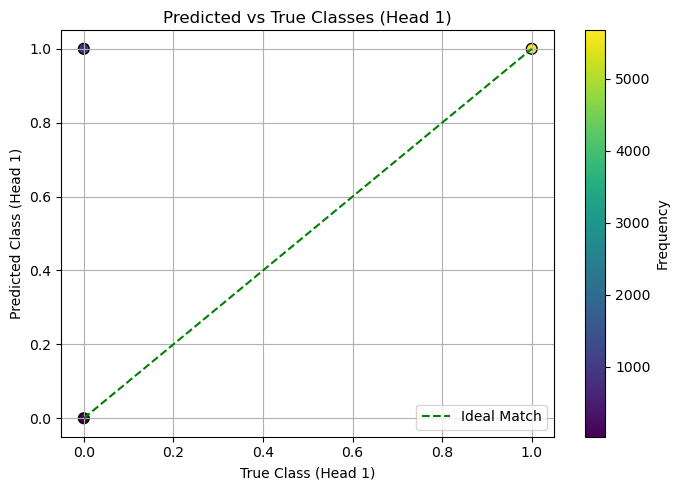

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


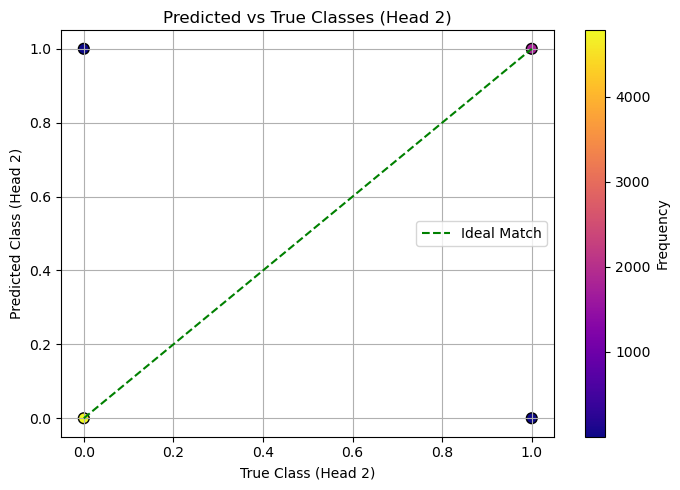

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


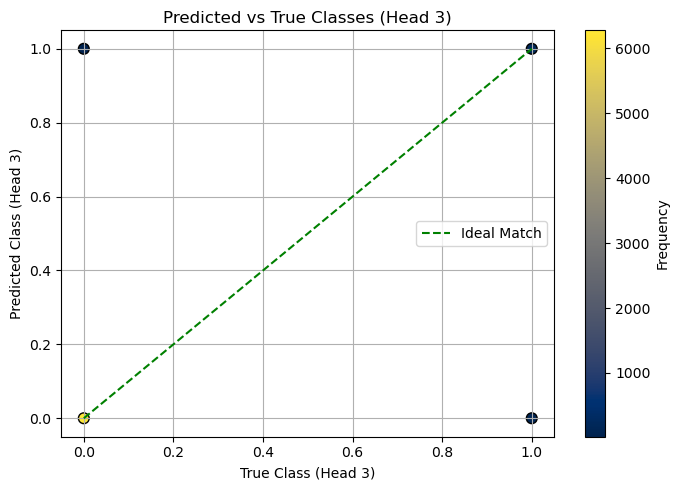

In [9]:
# ----------------- First Classification Head Plot -----------------
# Map back to original class labels
true_class1 = le_class.inverse_transform(all_class_labels)
pred_class1 = le_class.inverse_transform(all_class_preds)

df_plot1 = pd.DataFrame({
    "True": true_class1,
    "Pred": pred_class1
})

freq1 = df_plot1.groupby(["True", "Pred"]).size().reset_index(name='Count')

plt.figure(figsize=(7, 5))
scatter1 = plt.scatter(
    freq1["True"], freq1["Pred"],
    c=freq1["Count"], cmap='viridis', 
    s=60, alpha=1, edgecolors='k'
)

plt.plot([min(true_class1), max(true_class1)],
         [min(true_class1), max(true_class1)],
         'g--', label='Ideal Match')

plt.xlabel("True Class (Head 1)")
plt.ylabel("Predicted Class (Head 1)")
plt.title("Predicted vs True Classes (Head 1)")
plt.legend()
plt.colorbar(scatter1, label='Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig("class1_predicted_vs_true.jpg", format='jpg', dpi=300)
plt.savefig("class1_predicted_vs_true.eps", format='eps', dpi=300)
plt.show()

# ----------------- Second Classification Head Plot -----------------
true_class2 = le_class2.inverse_transform(all_class2_labels)
pred_class2 = le_class2.inverse_transform(all_class2_preds)

df_plot2 = pd.DataFrame({
    "True": true_class2,
    "Pred": pred_class2
})

freq2 = df_plot2.groupby(["True", "Pred"]).size().reset_index(name='Count')

plt.figure(figsize=(7, 5))
scatter2 = plt.scatter(
    freq2["True"], freq2["Pred"],
    c=freq2["Count"], cmap='plasma', 
    s=60, alpha=1, edgecolors='k'
)

plt.plot([min(true_class2), max(true_class2)],
         [min(true_class2), max(true_class2)],
         'g--', label='Ideal Match')

plt.xlabel("True Class (Head 2)")
plt.ylabel("Predicted Class (Head 2)")
plt.title("Predicted vs True Classes (Head 2)")
plt.legend()
plt.colorbar(scatter2, label='Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig("class2_predicted_vs_true.jpg", format='jpg', dpi=300)
plt.savefig("class2_predicted_vs_true.eps", format='eps', dpi=300)
plt.show()

# ----------------- Third Classification Head Plot -----------------
true_class3 = le_class3.inverse_transform(all_class3_labels)
pred_class3 = le_class3.inverse_transform(all_class3_preds)

df_plot3 = pd.DataFrame({
    "True": true_class3,
    "Pred": pred_class3
})

freq3 = df_plot3.groupby(["True", "Pred"]).size().reset_index(name='Count')

plt.figure(figsize=(7, 5))
scatter3 = plt.scatter(
    freq3["True"], freq3["Pred"],
    c=freq3["Count"], cmap='cividis',  # New colormap
    s=60, alpha=1, edgecolors='k'
)

plt.plot([min(true_class3), max(true_class3)],
         [min(true_class3), max(true_class3)],
         'g--', label='Ideal Match')

plt.xlabel("True Class (Head 3)")
plt.ylabel("Predicted Class (Head 3)")
plt.title("Predicted vs True Classes (Head 3)")
plt.legend()
plt.colorbar(scatter3, label='Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig("class3_predicted_vs_true.jpg", format='jpg', dpi=300)
plt.savefig("class3_predicted_vs_true.eps", format='eps', dpi=300)
plt.show()


Starting SHAP analysis...

X_plot shape: (50, 22)


  0%|          | 0/50 [00:00<?, ?it/s]

shap_values is list of 2 arrays.
shap_values[0].shape: (50, 22)
shap_values[1].shape: (50, 22)

Top features by global mean absolute SHAP values (Top 10):
1. platform_order_time_hour: 0.02137
2. order_push_time_hour: 0.01717
3. estimate_meal_prepare_time_hour: 0.01652
4. platform_order_time_minute: 0.01639
5. recipient_lat: 0.01073
6. order_push_time_minute: 0.01028
7. dispatch_time_hour: 0.00948
8. sender_lat: 0.00924
9. dispatch_time_minute: 0.00687
10. recipient_lng: 0.00601

Save global SHAP feature importance (top 10) to Results.txt...
Save global SHAP importance plot: global_shap_importance_head1.jpg
Save global SHAP importance plot: global_shap_importance_head1.eps


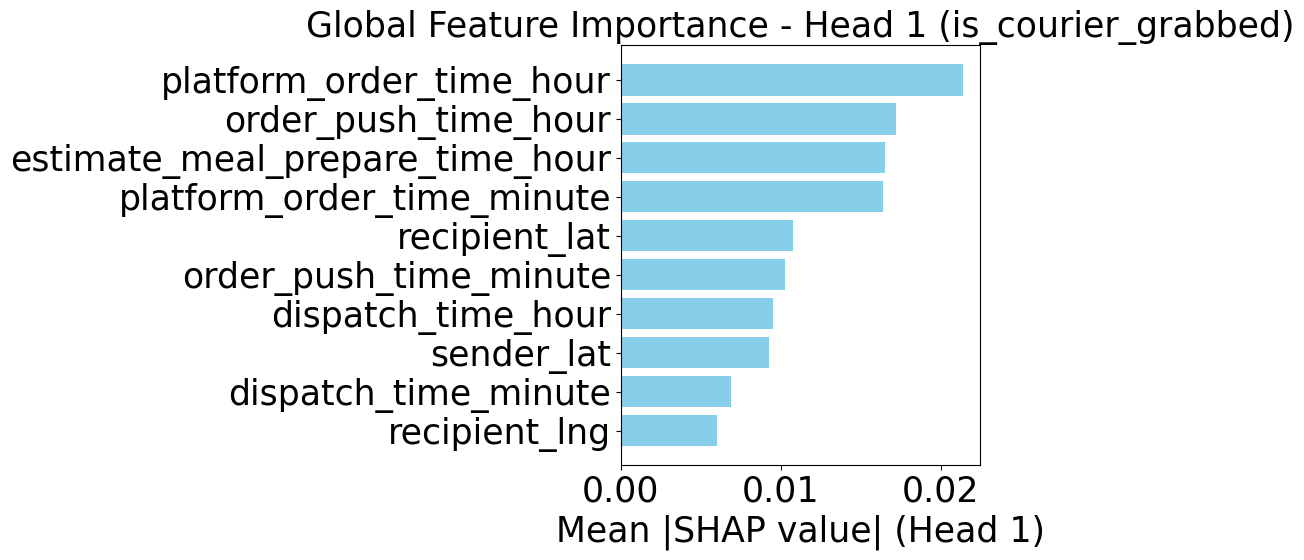

In [10]:
# SHAP Analysis
print("\nStarting SHAP analysis...")
# Prepare data for SHAP
X_explain = []
y_explain = []
for X_batch, y_class_batch, y_class2_batch, y_class3_batch in test_loader:
    X_explain.append(X_batch)
    y_explain.append(y_class_batch)
    if len(torch.cat(X_explain)) >= 100:
        break

X_explain = torch.cat(X_explain)[:100].to(device)
y_explain = torch.cat(y_explain)[:100].to(device)

# Define a function to predict class probabilities for SHAP
def model_predict_class_proba(input_numpy):
    input_tensor = torch.tensor(input_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits, _, _ = model(input_tensor)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
    return probs

# Initialize SHAP KernelExplainer
explainer = shap.KernelExplainer(
    model_predict_class_proba, 
    X_explain[:20].detach().cpu().numpy()  # background data
)

# Data to explain
X_plot = X_explain[:50].detach().cpu().numpy()  # shape: (50, n_features)
print(f"\nX_plot shape: {X_plot.shape}")

# Compute SHAP values for each class
shap_values = explainer.shap_values(X_plot)  # list of shape (n_classes, n_samples, n_features)

# Convert SHAP values to a fixed format
arr = np.stack(shap_values, axis=0)  # (50, 374, 5)
arr = np.transpose(arr, (2, 0, 1))  # (5, 50, 374)
shap_values_fixed = [arr[i] for i in range(arr.shape[0])]
print(f"shap_values is list of {len(shap_values_fixed)} arrays.")
for i, sv in enumerate(shap_values_fixed):
    print(f"shap_values[{i}].shape: {sv.shape}")

# Visualize SHAP values
try:
    feature_names = X.columns.tolist()  # Ensure feature names are from the original DataFrame
except:
    feature_names = [f"feature_{i}" for i in range(X_explain.shape[1])]

# Calculate global SHAP importance
all_shap_array = np.concatenate(shap_values_fixed, axis=0)  # (n_classes*n_samples, n_features)
global_shap_importance = np.mean(np.abs(all_shap_array), axis=0)  # (n_features,)

# Print top features by global mean absolute SHAP values
top_k = 10
top_k = min(top_k, len(global_shap_importance))  # avoid top_k > n_features
top_indices = np.argsort(global_shap_importance)[::-1][:top_k]

print("\nTop features by global mean absolute SHAP values (Top {}):".format(top_k))
for rank, idx in enumerate(top_indices, 1):
    feature_name = feature_names[idx] if idx < len(feature_names) else f"Feature_{idx}"
    print(f"{rank}. {feature_name}: {global_shap_importance[idx]:.5f}")

print(f"\nSave global SHAP feature importance (top {top_k}) to {report_filename}...")
with open(report_filename, 'a') as fw0:
    fw0.write(f"\nGlobal SHAP Feature Importance for {y_class_name} - Head1 (Top {top_k}):\n")
    for rank, idx in enumerate(top_indices, 1):
        feature_name = feature_names[idx] if idx < len(feature_names) else f"Feature_{idx}"
        fw0.write(f"{rank}. {feature_name}: {global_shap_importance[idx]:.5f}\n")

# Define the plot filename
plot_filename_jpg = f"global_shap_importance_head1.jpg"
plot_filename_eps = f"global_shap_importance_head1.eps"


# Plot global SHAP importance
# -------- Normal version with real feature names --------

# Reverse order for better visualization
plot_feature_names = [
    feature_names[i] if i < len(feature_names) else f"Feature_{i}"
    for i in top_indices[::-1]
]
plt.figure(figsize=(10,6))
plt.barh(
    plot_feature_names,
    global_shap_importance[top_indices][::-1],
    color='skyblue'
)
plt.xlabel("Mean |SHAP value| (Head 1)", fontsize=25)
# plt.ylabel("Features", fontsize=20) 
plt.tick_params(axis='x', labelsize=25)
plt.tick_params(axis='y', labelsize=25)
wrapped_title = "\n".join(textwrap.wrap(f"Global Feature Importance - Head 1 ({y_class_name})", width=70))
plt.title(wrapped_title, fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(plot_filename_jpg, format='jpg',dpi=300, bbox_inches="tight")
plt.savefig(plot_filename_eps, format='eps', dpi=300, bbox_inches="tight")
print(f"Save global SHAP importance plot: {plot_filename_jpg}")
print(f"Save global SHAP importance plot: {plot_filename_eps}")
plt.show()


Starting SHAP analysis for Classification Head 2...


  0%|          | 0/50 [00:00<?, ?it/s]

shap_values2 is list of 2 arrays.

Top features by SHAP values (Head 2):
1. platform_order_time_weekday: 0.14878
2. order_push_time_weekday: 0.08221
3. estimate_arrived_time_weekday: 0.07961
4. estimate_meal_prepare_time_weekday: 0.06795
5. dispatch_time_weekday: 0.03968
6. order_push_time_hour: 0.01690
7. estimate_meal_prepare_time_hour: 0.01466
8. estimate_arrived_time_hour: 0.01238
9. recipient_lng: 0.00647
10. platform_order_time_hour: 0.00588


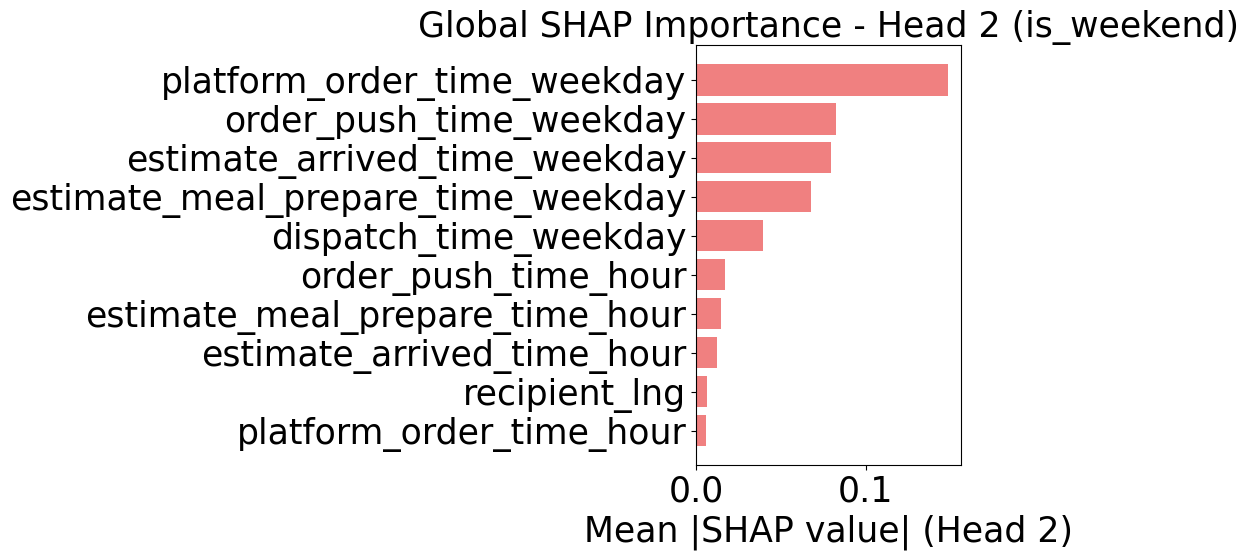

In [11]:
print("\nStarting SHAP analysis for Classification Head 2...")

# Define a function to predict class probabilities for SHAP (Head 2)
def model_predict_class2_proba(input_numpy):
    input_tensor = torch.tensor(input_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        _, logits2, _ = model(input_tensor)
        probs = torch.softmax(logits2, dim=1).detach().cpu().numpy()
    return probs

# Initialize SHAP KernelExplainer
explainer2 = shap.KernelExplainer(
    model_predict_class2_proba, 
    X_explain[:20].detach().cpu().numpy()  # background data
)

# Data to explain
X_plot = X_explain[:50].detach().cpu().numpy()

# Compute SHAP values
shap_values2 = explainer2.shap_values(X_plot)

# Convert SHAP values
arr2 = np.stack(shap_values2, axis=0)
arr2 = np.transpose(arr2, (2, 0, 1))  # (num_classes2, n_samples, n_features)
shap_values2_fixed = [arr2[i] for i in range(arr2.shape[0])]
print(f"shap_values2 is list of {len(shap_values2_fixed)} arrays.")

# Global SHAP importance
all_shap_array2 = np.concatenate(shap_values2_fixed, axis=0)
global_shap_importance2 = np.mean(np.abs(all_shap_array2), axis=0)

# Top features
top_indices2 = np.argsort(global_shap_importance2)[::-1][:top_k]

print("\nTop features by SHAP values (Head 2):")
for rank, idx in enumerate(top_indices2, 1):
    feature_name = feature_names[idx] if idx < len(feature_names) else f"Feature_{idx}"
    print(f"{rank}. {feature_name}: {global_shap_importance2[idx]:.5f}")

# Save report
with open(report_filename, 'a') as fw0:
    fw0.write(f"\nGlobal SHAP Feature Importance for {y_class2_name} - Head2 (Top {top_k}):\n")
    for rank, idx in enumerate(top_indices2, 1):
        feature_name = feature_names[idx] if idx < len(feature_names) else f"Feature_{idx}"
        fw0.write(f"{rank}. {feature_name}: {global_shap_importance2[idx]:.5f}\n")

# Plot
plt.figure(figsize=(10,6))
plot_feature_names2 = [feature_names[i] for i in top_indices2[::-1]]
plt.barh(plot_feature_names2, global_shap_importance2[top_indices2][::-1], color='lightcoral')
plt.xlabel("Mean |SHAP value| (Head 2)", fontsize=25)
# plt.ylabel("Features", fontsize=20) 
plt.tick_params(axis='x', labelsize=25)
plt.tick_params(axis='y', labelsize=25)
plt.title(f"Global SHAP Importance - Head 2 ({y_class2_name})", fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("global_shap_importance_head2.jpg", dpi=300, bbox_inches="tight")
plt.savefig("global_shap_importance_head2.eps", dpi=300, bbox_inches="tight")
plt.show()



Starting SHAP analysis for Classification Head 3...


  0%|          | 0/50 [00:00<?, ?it/s]

shap_values3 is list of 2 arrays.

Top features by SHAP values (Head 3):
1. order_push_time_hour: 0.11094
2. estimate_arrived_time_hour: 0.11093
3. platform_order_time_hour: 0.09280
4. order_push_time_weekday: 0.08658
5. dispatch_time_hour: 0.07749
6. estimate_arrived_time_weekday: 0.04912
7. platform_order_time_minute: 0.04711
8. dispatch_time_minute: 0.04686
9. order_push_time_minute: 0.03853
10. platform_order_time_weekday: 0.02465


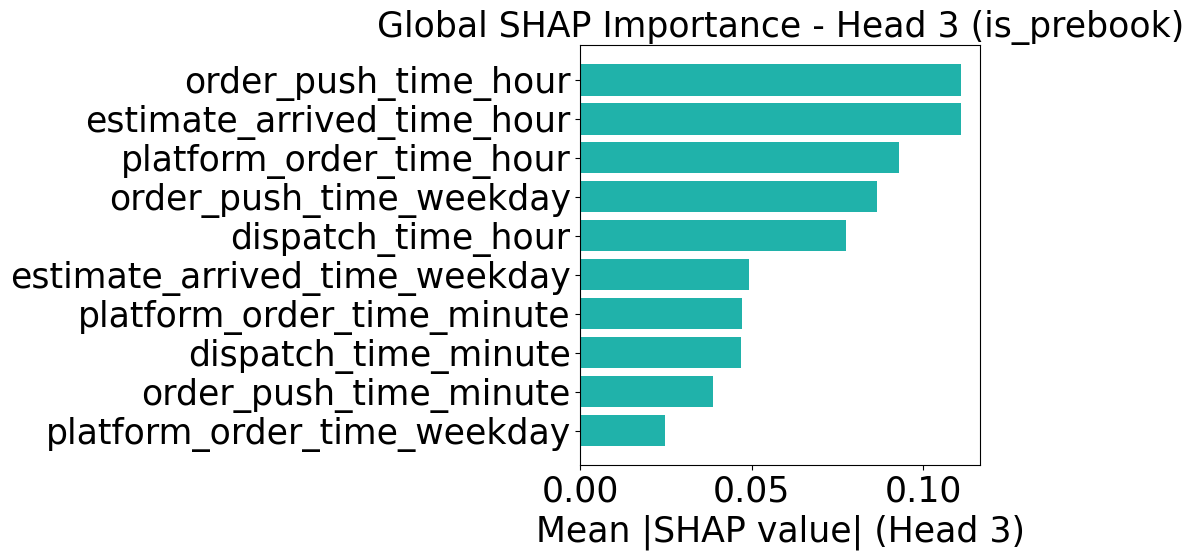

In [12]:
print("\nStarting SHAP analysis for Classification Head 3...")

# Define a function to predict class probabilities for SHAP (Head 3)
def model_predict_class3_proba(input_numpy):
    input_tensor = torch.tensor(input_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        _, _, logits3 = model(input_tensor)  # Get logits for head3
        probs = torch.softmax(logits3, dim=1).detach().cpu().numpy()
    return probs

# Initialize SHAP KernelExplainer
explainer3 = shap.KernelExplainer(
    model_predict_class3_proba, 
    X_explain[:20].detach().cpu().numpy()  # background data
)

# Data to explain
X_plot = X_explain[:50].detach().cpu().numpy()

# Compute SHAP values
shap_values3 = explainer3.shap_values(X_plot)

# Convert SHAP values to consistent format
arr3 = np.stack(shap_values3, axis=0)
arr3 = np.transpose(arr3, (2, 0, 1))  # (num_classes3, n_samples, n_features)
shap_values3_fixed = [arr3[i] for i in range(arr3.shape[0])]
print(f"shap_values3 is list of {len(shap_values3_fixed)} arrays.")

# Global SHAP importance
all_shap_array3 = np.concatenate(shap_values3_fixed, axis=0)
global_shap_importance3 = np.mean(np.abs(all_shap_array3), axis=0)

# Top features
top_indices3 = np.argsort(global_shap_importance3)[::-1][:top_k]

print("\nTop features by SHAP values (Head 3):")
for rank, idx in enumerate(top_indices3, 1):
    feature_name = feature_names[idx] if idx < len(feature_names) else f"Feature_{idx}"
    print(f"{rank}. {feature_name}: {global_shap_importance3[idx]:.5f}")

# Save report
with open(report_filename, 'a') as fw0:
    fw0.write(f"\nGlobal SHAP Feature Importance for {y_class3_name} - Head3 (Top {top_k}):\n")
    for rank, idx in enumerate(top_indices3, 1):
        feature_name = feature_names[idx] if idx < len(feature_names) else f"Feature_{idx}"
        fw0.write(f"{rank}. {feature_name}: {global_shap_importance3[idx]:.5f}\n")

# Plot
plt.figure(figsize=(10,6))
plot_feature_names3 = [feature_names[i] for i in top_indices3[::-1]]
plt.barh(plot_feature_names3, global_shap_importance3[top_indices3][::-1], color='lightseagreen')
plt.xlabel("Mean |SHAP value| (Head 3)", fontsize=25)
plt.tick_params(axis='x', labelsize=25)
plt.tick_params(axis='y', labelsize=25)
plt.title(f"Global SHAP Importance - Head 3 ({y_class3_name})", fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("global_shap_importance_head3.jpg", dpi=300, bbox_inches="tight")
plt.savefig("global_shap_importance_head3.eps", dpi=300, bbox_inches="tight")
plt.show()
